# Выделение разломов по 3D сейсмическим данным
Ансамбль из 3 моделей (2× BasicUNet + SegResNet) с TTA.  
Подробное описание подхода — в файле `report.md`.

In [1]:
!pip install -q monai==1.5.2

import os, glob, time, math, random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from itertools import product
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast
from monai.networks.nets import BasicUNet, SegResNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 30.5 MB/s eta 0:00:0000:0100:01


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-24 18:19:12.094584: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777054752.329438      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777054752.401082      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777054752.936516      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777054752.936573      55 computation_placer.cc:1

Device: cuda
GPU: Tesla T4


In [2]:
# пути к данным
def find_dir(*options):
    for p in options:
        if os.path.exists(p):
            return p
    return None

DATA_DIR = find_dir(
    "/kaggle/input/datasets/malik9/synth-seis-data",
    "/kaggle/input/synth-seis-data",
)
CKPT_DIR = find_dir(
    "/kaggle/input/datasets/chikeung/block3-swin-ckpts",
    "/kaggle/input/block3-swin-ckpts",
)

print(f"Data:  {DATA_DIR}")
print(f"Ckpts: {CKPT_DIR}")

Data:  /kaggle/input/datasets/malik9/synth-seis-data
Ckpts: /kaggle/input/datasets/chikeung/block3-swin-ckpts


## Данные

Train: 200, Val: 20
seis: (128, 128, 128), fault unique: [0. 1.]
Доля разломов: 3.23% ± 0.82%


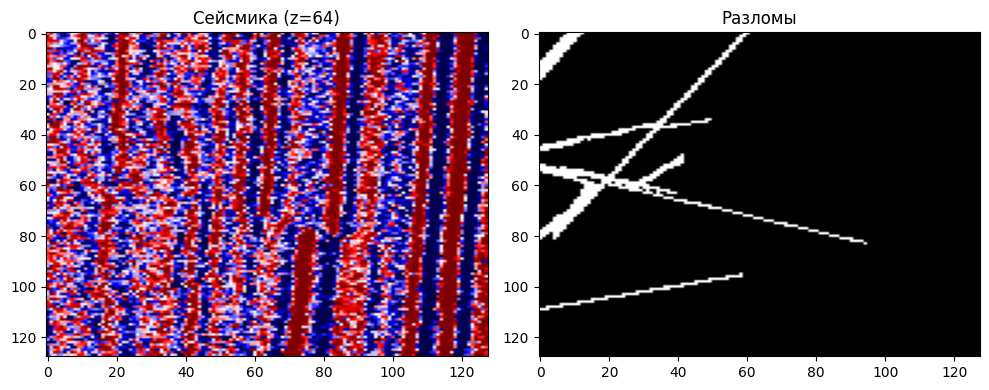

In [3]:
train_files = sorted(glob.glob(os.path.join(DATA_DIR, "train", "*.npz")))
val_files = sorted(glob.glob(os.path.join(DATA_DIR, "validation", "*.npz")))
print(f"Train: {len(train_files)}, Val: {len(val_files)}")

sample = np.load(train_files[0])
print(f"seis: {sample['seis'].shape}, fault unique: {np.unique(sample['fault'])}")

fracs = [np.load(f)["fault"].mean() * 100 for f in train_files]
print(f"Доля разломов: {np.mean(fracs):.2f}% ± {np.std(fracs):.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample["seis"][64], cmap="seismic", aspect="auto")
axes[0].set_title("Сейсмика (z=64)")
axes[1].imshow(sample["fault"][64], cmap="gray", aspect="auto")
axes[1].set_title("Разломы")
plt.tight_layout()
plt.show()

## Предобработка и датасет

In [4]:
def normalize(x):
    return (x - x.mean()) / (x.std() + 1e-6)

class SeisDataset(Dataset):
    def __init__(self, files, augment=False):
        self.files = files
        self.augment = augment

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        d = np.load(self.files[idx])
        seis = normalize(d["seis"].astype(np.float32))
        lbl = d["fault"].astype(np.float32)

        if self.augment:
            # flips
            for ax in range(3):
                if random.random() < 0.5:
                    seis = np.flip(seis, ax).copy()
                    lbl = np.flip(lbl, ax).copy()
            # rot90 вокруг вертикальной оси
            k = random.randint(0, 3)
            if k:
                seis = np.rot90(seis, k, axes=(1, 2)).copy()
                lbl = np.rot90(lbl, k, axes=(1, 2)).copy()
            # яркость
            if random.random() < 0.5:
                seis = seis * random.uniform(0.9, 1.1) + random.uniform(-0.1, 0.1)
            # шум
            if random.random() < 0.3:
                seis += np.random.randn(*seis.shape).astype(np.float32) * 0.05

        return (torch.from_numpy(seis).unsqueeze(0).float(),
                torch.from_numpy(lbl).unsqueeze(0).float())

val_ds = SeisDataset(val_files, augment=False)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)
print(f"Val: {len(val_loader)} объёмов")

Val: 20 объёмов


## Модели

In [5]:
def create_v3():
    return BasicUNet(spatial_dims=3, in_channels=1, out_channels=1,
                     features=(32, 64, 128, 256, 256, 32))

def create_b():
    return BasicUNet(spatial_dims=3, in_channels=1, out_channels=1,
                     features=(48, 96, 192, 384, 384, 48))

def create_segresnet():
    return SegResNet(spatial_dims=3, in_channels=1, out_channels=1,
                     init_filters=32, blocks_down=(1, 2, 2, 4), blocks_up=(1, 1, 1),
                     dropout_prob=0.2, norm="instance")

CKPT_V3  = os.path.join(CKPT_DIR, "best_final.pt")
CKPT_B   = os.path.join(CKPT_DIR, "best_basicunet_b.pt")
CKPT_SEG = os.path.join(CKPT_DIR, "best_segresnet.pt")

def load_model(create_fn, ckpt_path):
    model = create_fn().to(device)
    ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    sd = ck["model"] if "model" in ck else ck
    model.load_state_dict(sd)
    model.eval()
    n = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"  {os.path.basename(ckpt_path)}: {n:.2f}M params")
    return model

print("Загрузка моделей:")
for fn, path in [(create_v3, CKPT_V3), (create_b, CKPT_B), (create_segresnet, CKPT_SEG)]:
    m = load_model(fn, path); del m
torch.cuda.empty_cache()
print("OK")

Загрузка моделей:
BasicUNet features: (32, 64, 128, 256, 256, 32).
  best_final.pt: 13.87M params
BasicUNet features: (48, 96, 192, 384, 384, 48).
  best_basicunet_b.pt: 31.21M params
  best_segresnet.pt: 18.79M params
OK


## Код обучения (для справки)
Ниже показан train loop в том виде, в котором обучались модели.  
Запускать не нужно — обучение каждой модели заняло 6-15 часов на T4.

In [6]:
# === ЭТОТ БЛОК НЕ ЗАПУСКАЕТСЯ, ТОЛЬКО ДЛЯ СПРАВКИ ===
# Пример для SegResNet, остальные модели обучались аналогично

if False:  # чтобы случайно не запустить
    from monai.losses import DiceCELoss
    from monai.transforms import Rand3DElasticd
    from torch.amp import GradScaler

    EPOCHS = 100
    LR = 2e-4

    model = create_segresnet().to(device)
    loss_fn = DiceCELoss(sigmoid=True, lambda_dice=1.0, lambda_ce=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
    scaler = GradScaler()

    # warmup 5 эпох, потом cosine decay
    def lr_lambda(epoch):
        if epoch < 5:
            return (epoch + 1) / 5
        p = (epoch - 5) / max(1, EPOCHS - 5)
        return 0.5 * (1 + math.cos(math.pi * p))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    train_ds = SeisDataset(train_files, augment=True)
    train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)

    best_dice = 0
    for epoch in range(EPOCHS):
        model.train()
        for seis, lbl in train_loader:
            seis, lbl = seis.to(device), lbl.to(device)
            optimizer.zero_grad()
            with autocast("cuda"):
                logits = model(seis)
                loss = loss_fn(logits, lbl)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        scheduler.step()

        # валидация
        model.eval()
        dices = []
        with torch.no_grad():
            for seis, lbl in val_loader:
                seis, lbl = seis.to(device), lbl.to(device)
                with autocast("cuda"):
                    pred = (torch.sigmoid(model(seis)) > 0.5).float()
                inter = (pred * lbl).sum().item()
                denom = pred.sum().item() + lbl.sum().item()
                dices.append((2 * inter + 1e-6) / (denom + 1e-6))
        val_dice = np.mean(dices)

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save({"model": model.state_dict(), "epoch": epoch,
                         "best_dice": best_dice}, "best_segresnet.pt")
        print(f"ep {epoch+1}/{EPOCHS}  val_dice {val_dice:.4f}  best {best_dice:.4f}")

## TTA и инференс на валидации

In [7]:
@torch.no_grad()
def tta_predict(model, x):
    """8 вариантов: все комбинации flip по 3 осям"""
    flips_list = [(), (2,), (3,), (4,), (2,3), (2,4), (3,4), (2,3,4)]
    preds = []
    for flips in flips_list:
        xi = x
        for ax in flips:
            xi = torch.flip(xi, dims=[ax])
        with autocast("cuda"):
            p = torch.sigmoid(model(xi))
        for ax in flips:
            p = torch.flip(p, dims=[ax])
        preds.append(p.float())
    return torch.stack(preds).mean(0)

# val данные в память
val_data = []
for seis, lbl in val_loader:
    val_data.append((seis, lbl.numpy().squeeze()))
targets = np.array([d[1] for d in val_data], dtype=np.float32)

# TTA-предсказания для каждой модели
print("TTA на валидации...")
val_probs = {}
for name, fn, path in [("v3", create_v3, CKPT_V3),
                        ("b",  create_b,  CKPT_B),
                        ("seg", create_segresnet, CKPT_SEG)]:
    t0 = time.time()
    model = load_model(fn, path)
    probs = np.zeros((len(val_data), 128, 128, 128), dtype=np.float32)
    for i, (seis, _) in enumerate(val_data):
        probs[i] = tta_predict(model, seis.to(device)).squeeze().cpu().numpy()
    val_probs[name] = probs
    del model; torch.cuda.empty_cache()
    print(f"  {name}: {time.time()-t0:.0f}s")

TTA на валидации...
BasicUNet features: (32, 64, 128, 256, 256, 32).
  best_final.pt: 13.87M params
  v3: 22s
BasicUNet features: (48, 96, 192, 384, 384, 48).
  best_basicunet_b.pt: 31.21M params
  b: 46s
  best_segresnet.pt: 18.79M params
  seg: 22s


## Метрики отдельных моделей

In [8]:
def compute_metrics(pred, target, eps=1e-6):
    tp = (pred * target).sum()
    fp = (pred * (1 - target)).sum()
    fn = ((1 - pred) * target).sum()
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    prec = (tp + eps) / (tp + fp + eps)
    rec = (tp + eps) / (tp + fn + eps)
    return dice, iou, prec, rec

print(f"{'Модель':<12} {'Dice':>8} {'IoU':>8} {'Prec':>8} {'Recall':>8}")
print("-" * 48)
for name in ["v3", "b", "seg"]:
    preds = (val_probs[name] > 0.5).astype(np.float32)
    metrics = [compute_metrics(preds[i], targets[i]) for i in range(len(targets))]
    vals = [np.mean([m[j] for m in metrics]) for j in range(4)]
    print(f"{name:<12} {vals[0]:>8.4f} {vals[1]:>8.4f} {vals[2]:>8.4f} {vals[3]:>8.4f}")

Модель           Dice      IoU     Prec   Recall
------------------------------------------------
v3             0.8107   0.6829   0.8018   0.8204
b              0.8108   0.6831   0.8045   0.8178
seg            0.7984   0.6656   0.7826   0.8158


## Ансамбль: подбор весов и порога

In [9]:
P = val_probs

def ensemble_dice(wv, wb, ws, thr):
    s = wv + wb + ws
    if s == 0: return 0
    avg = (wv * P["v3"] + wb * P["b"] + ws * P["seg"]) / s
    pred = (avg > thr).astype(np.float32)
    dices = []
    for i in range(len(targets)):
        inter = (pred[i] * targets[i]).sum()
        denom = pred[i].sum() + targets[i].sum()
        dices.append((2 * inter + 1e-6) / (denom + 1e-6))
    return np.mean(dices)

weights = [0, 0.5, 1.0, 1.5, 2.0]
thresholds = [0.42, 0.44, 0.46, 0.48, 0.50, 0.52]

results = []
for wv, wb, ws in product(weights, repeat=3):
    if wv + wb + ws == 0: continue
    for thr in thresholds:
        results.append((wv, wb, ws, thr, ensemble_dice(wv, wb, ws, thr)))

results.sort(key=lambda x: -x[4])

print(f"{'w_v3':>6} {'w_b':>6} {'w_seg':>6} {'thr':>6}  {'Dice':>8}")
print("-" * 42)
for r in results[:10]:
    print(f"{r[0]:>6.1f} {r[1]:>6.1f} {r[2]:>6.1f} {r[3]:>6.2f}  {r[4]:.5f}")

  w_v3    w_b  w_seg    thr      Dice
------------------------------------------
   1.0    1.0    0.5   0.48  0.81473
   2.0    2.0    1.0   0.48  0.81473
   1.5    1.5    0.5   0.48  0.81469
   1.5    2.0    1.0   0.48  0.81469
   1.0    1.0    0.5   0.46  0.81467
   2.0    2.0    1.0   0.46  0.81467
   2.0    1.5    1.0   0.48  0.81464
   1.0    1.0    0.5   0.50  0.81464
   2.0    2.0    1.0   0.50  0.81464
   1.5    1.5    1.0   0.48  0.81464


## Финальные метрики

In [10]:
wv, wb, ws, thr = results[0][:4]
total = wv + wb + ws
ens_prob = (wv * P["v3"] + wb * P["b"] + ws * P["seg"]) / total
ens_pred = (ens_prob > thr).astype(np.float32)

dices, ious, precs, recs = [], [], [], []
for i in range(len(targets)):
    d, iou, p, r = compute_metrics(ens_pred[i], targets[i])
    dices.append(d); ious.append(iou); precs.append(p); recs.append(r)

print(f"Веса: v3={wv}, B={wb}, SegResNet={ws}, порог={thr}")
print(f"Dice:      {np.mean(dices):.4f} ± {np.std(dices):.4f}")
print(f"IoU:       {np.mean(ious):.4f} ± {np.std(ious):.4f}")
print(f"Precision: {np.mean(precs):.4f} ± {np.std(precs):.4f}")
print(f"Recall:    {np.mean(recs):.4f} ± {np.std(recs):.4f}")

print(f"\nДля сравнения:")
print(f"  v3 одна:       {ensemble_dice(1,0,0, 0.5):.4f}")
print(f"  B одна:        {ensemble_dice(0,1,0, 0.5):.4f}")
print(f"  SegResNet одна:{ensemble_dice(0,0,1, 0.5):.4f}")
print(f"  v3 + B:        {ensemble_dice(1,1,0, 0.48):.4f}")
print(f"  Ансамбль:      {results[0][4]:.4f}")

Веса: v3=1.0, B=1.0, SegResNet=0.5, порог=0.48
Dice:      0.8147 ± 0.0320
IoU:       0.6886 ± 0.0454
Precision: 0.8030 ± 0.0310
Recall:    0.8273 ± 0.0393

Для сравнения:
  v3 одна:       0.8107
  B одна:        0.8108
  SegResNet одна:0.7984
  v3 + B:        0.8140
  Ансамбль:      0.8147


Dice по объёмам:
     0.npz: 0.8071
     1.npz: 0.7971
    10.npz: 0.8544
    11.npz: 0.8135
    12.npz: 0.8139
    13.npz: 0.8388
    14.npz: 0.7596
    15.npz: 0.8099
    16.npz: 0.7915
    17.npz: 0.8768
    18.npz: 0.8203
    19.npz: 0.8177
     2.npz: 0.8536
     3.npz: 0.8211
     4.npz: 0.7838
     5.npz: 0.8443
     6.npz: 0.7666
     7.npz: 0.7527
     8.npz: 0.8307
     9.npz: 0.8409


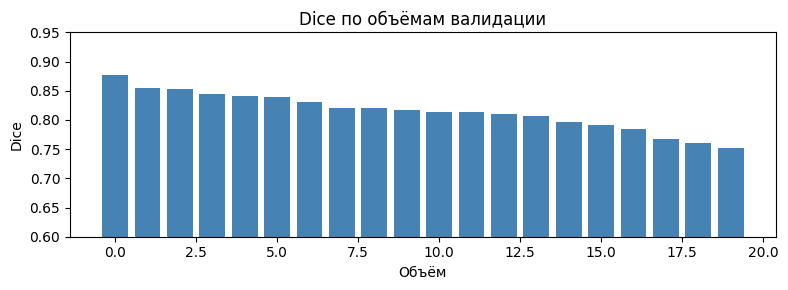

In [11]:
print("Dice по объёмам:")
for i, f in enumerate(val_files):
    print(f"  {os.path.basename(f):>8s}: {dices[i]:.4f}")

plt.figure(figsize=(8, 3))
plt.bar(range(len(dices)), sorted(dices, reverse=True), color="steelblue")
plt.xlabel("Объём")
plt.ylabel("Dice")
plt.title("Dice по объёмам валидации")
plt.ylim(0.6, 0.95)
plt.tight_layout()
plt.show()

## F3 Netherlands (out-of-distribution)

In [12]:
F3_DIR = os.path.join(DATA_DIR, "prediction", "f3d")
F3_SHAPE = (512, 384, 128)

f3_seis = np.fromfile(os.path.join(F3_DIR, "gxl.dat"), dtype=np.float32).reshape(F3_SHAPE)
f3_norm = normalize(f3_seis)
wu_ref = np.fromfile(os.path.join(F3_DIR, "fpx.dat"), dtype=np.float32).reshape(F3_SHAPE)
print(f"F3: {f3_seis.shape}, Wu ref frac>0.5: {(wu_ref>0.5).mean()*100:.2f}%")

# sliding window с TTA
@torch.no_grad()
def predict_f3(model, vol, patch=128, stride=64):
    D, H, W = vol.shape
    pD = math.ceil(D / stride) * stride
    pH = math.ceil(H / stride) * stride
    padded = np.pad(vol, ((0, pD-D), (0, pH-H), (0, 0)), mode="reflect")
    prob_sum = np.zeros_like(padded)
    count = np.zeros_like(padded)

    for d0 in range(0, pD - patch + 1, stride):
        for h0 in range(0, pH - patch + 1, stride):
            chunk = padded[d0:d0+patch, h0:h0+patch, :patch]
            x = torch.from_numpy(chunk).unsqueeze(0).unsqueeze(0).to(device)
            p = tta_predict(model, x).squeeze().cpu().numpy()
            prob_sum[d0:d0+patch, h0:h0+patch, :patch] += p
            count[d0:d0+patch, h0:h0+patch, :patch] += 1

    return (prob_sum / np.maximum(count, 1))[:D, :H, :W]

f3_probs = {}
for name, fn, path in [("v3", create_v3, CKPT_V3),
                        ("b",  create_b,  CKPT_B),
                        ("seg", create_segresnet, CKPT_SEG)]:
    t0 = time.time()
    model = load_model(fn, path)
    f3_probs[name] = predict_f3(model, f3_norm)
    del model; torch.cuda.empty_cache()
    print(f"  {name}: {time.time()-t0:.0f}s, frac>0.5: {(f3_probs[name]>0.5).mean()*100:.2f}%")

f3_ens = (wv * f3_probs["v3"] + wb * f3_probs["b"] + ws * f3_probs["seg"]) / total
print(f"\nАнсамбль frac>{thr}: {(f3_ens>thr).mean()*100:.2f}%")
print(f"Wu ref   frac>0.5:  {(wu_ref>0.5).mean()*100:.2f}%")

F3: (512, 384, 128), Wu ref frac>0.5: 3.35%
BasicUNet features: (32, 64, 128, 256, 256, 32).
  best_final.pt: 13.87M params
  v3: 39s, frac>0.5: 2.65%
BasicUNet features: (48, 96, 192, 384, 384, 48).
  best_basicunet_b.pt: 31.21M params
  b: 88s, frac>0.5: 2.90%
  best_segresnet.pt: 18.79M params
  seg: 40s, frac>0.5: 1.88%

Ансамбль frac>0.48: 2.37%
Wu ref   frac>0.5:  3.35%


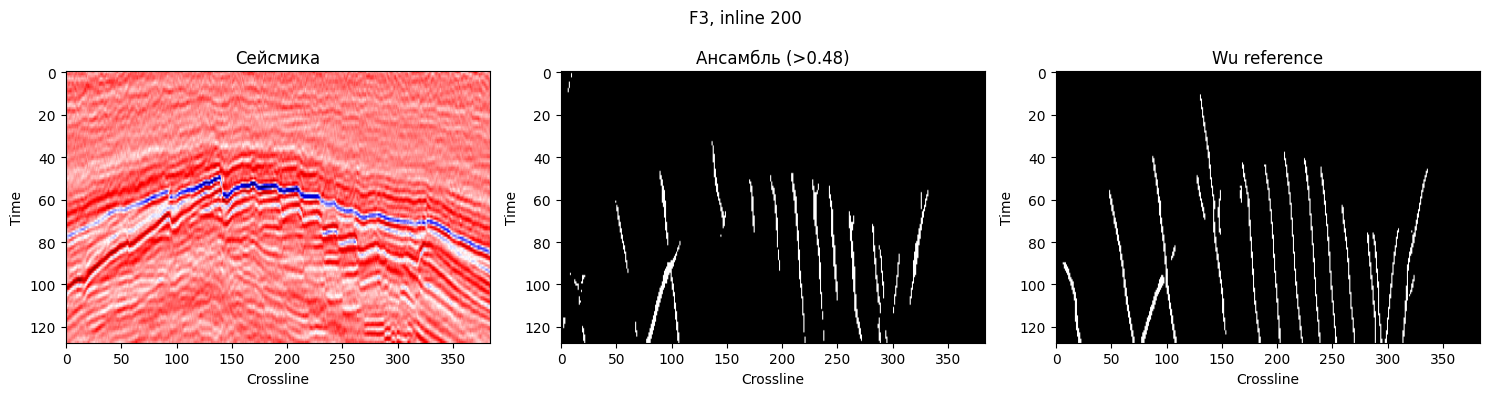

In [13]:
sl = 200
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(f3_seis[sl].T, cmap="seismic", aspect="auto")
axes[0].set_title("Сейсмика")
axes[1].imshow((f3_ens[sl] > thr).T, cmap="gray", aspect="auto")
axes[1].set_title(f"Ансамбль (>{thr})")
axes[2].imshow((wu_ref[sl] > 0.5).T, cmap="gray", aspect="auto")
axes[2].set_title("Wu reference")
for ax in axes:
    ax.set_xlabel("Crossline"); ax.set_ylabel("Time")
plt.suptitle(f"F3, inline {sl}")
plt.tight_layout()
plt.savefig("/kaggle/working/f3_comparison.png", dpi=150)
plt.show()